# Welfare Bot - User Comparison Analysis

Tässä notebookissa vertailen kahden käyttäjän hyvinvointiprofiileja.
Tavoitteena on nähdä, miten käyttäjien hyvinvointi eroaa eri mittareiden perusteella ja miten hyvinvointi muuttuu ajan myötä.
Tällainen analyysi voi auttaa Welfare Bot projektissa tunnistamaan käyttäjiä, jotka saattavat tarvita enemmän tukea tai seurantaa.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Datan lataaminen

Lataan cleaned-datasetin, jotta voin vertailla käyttäjiä ilman suuria puuttuvien arvojen ongelmia.

In [3]:
data = pd.read_csv("../data/welfare_bot_metrics_cleaned.csv")

data["date"] = pd.to_datetime(data["date"]) #  muuttaa "date" sarakkeen datetime-muotoon, jotta sitä voidaan käyttää aikaperusteisissa analyyseissä

data.head()

,date,user_name,email,mood_score,sleep_score,food_score,hydration_score,medication_score,social_score,overall_score,risk_level
0,2025-01-01,Aino Mäkinen,aino.makinen@demo.fi,4.40,3.94,2.99,1.00,0.88,3.38,8.890,low
1,2025-01-02,Aino Mäkinen,aino.makinen@demo.fi,4.83,4.31,2.66,0.96,0.86,3.27,8.980,low
2,2025-01-03,Aino Mäkinen,aino.makinen@demo.fi,4.30,3.24,2.28,0.80,0.82,3.66,7.670,low
3,2025-01-04,Aino Mäkinen,aino.makinen@demo.fi,3.84,3.44,3.00,0.79,0.91,2.79,7.765,NaN
4,2025-01-05,Aino Mäkinen,aino.makinen@demo.fi,3.99,4.05,2.46,0.94,0.85,3.36,8.250,low


## Käyttäjien tarkastelu

Tarkistan ensin, mitä käyttäjiä datassa on.

In [5]:
data["user_name"].unique()

array(['Aino Mäkinen', 'Eino Virtanen', 'Lempi Korhonen', 'Urho Leinonen'],
      dtype=object)

## Käyttäjien valinta

Valitsen kaksi käyttäjää vertailua varten.
Vertailen heidän hyvinvointiprofiilejaan sekä overall_score-kehitystä ajan myötä.

In [6]:
user_1 = "Aino Mäkinen"
user_2 = "Urho Leinonen"

user1_data = data[data["user_name"] == user_1]
user2_data = data[data["user_name"] == user_2]

## Keskimääräisten hyvinvointimittareiden vertailu

Lasketaan molempien käyttäjien keskimääräiset hyvinvointiarvot.
Näin voidaan nähdä, millä hyvinvoinnin osa-alueilla käyttäjien välillä on suurimmat erot.

In [8]:
features = [
    "mood_score",
    "sleep_score",
    "food_score",
    "hydration_score",
    "medication_score",
    "social_score"
]

user1_means = user1_data[features].mean()
user2_means = user2_data[features].mean()

comparison = pd.DataFrame({
    user_1: user1_means,
    user_2: user2_means
})

comparison

,Aino Mäkinen,Urho Leinonen
mood_score,4.324200,3.375867
sleep_score,4.011933,2.678400
food_score,2.762733,2.432667
hydration_score,0.869933,0.546867
medication_score,0.891667,0.889133
social_score,3.611000,1.952600


## Radar chart - käyttäjien hyvinvointiprofiilit

Radar-visualisointi auttaa vertailemaan käyttäjien hyvinvointiprofiileja eri hyvinvointitekijöiden perusteella.
Suurempi arvo tarkoittaa parempaa hyvinvoinnin tasoa kyseisellä osa-alueella.

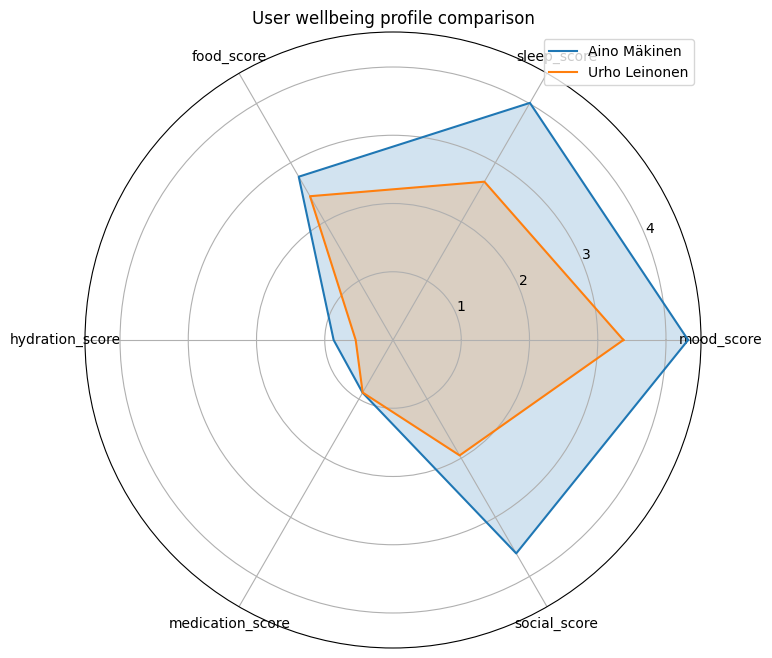

In [10]:
# otetaan mittareiden nimet radar chartia varten
labels = features

# otetaan molempien käyttäjien keskiarvot listaksi
user1_values = list(user1_means.values)
user2_values = list(user2_means.values)

# luodaan kulmat radar chartiin
angles = np.linspace(
    0,
    2 * np.pi,
    len(labels),
    endpoint=False
)

# lisätään ensimmäinen arvo uudelleen loppuun,
# jotta radar chart sulkeutuu kunnolla
user1_values.append(user1_values[0])
user2_values.append(user2_values[0])

angles = np.append(angles, angles[0])

# luodaan kuva
fig, ax = plt.subplots(
    figsize=(8,8),
    subplot_kw={"polar": True}
)

# ensimmäisen käyttäjän viiva
ax.plot(
    angles,
    user1_values,
    label=user_1
)

# täytetään alue hieman läpinäkyvästi
ax.fill(
    angles,
    user1_values,
    alpha=0.2
)

# toisen käyttäjän viiva
ax.plot(
    angles,
    user2_values,
    label=user_2
)

# täytetään alue hieman läpinäkyvästi
ax.fill(
    angles,
    user2_values,
    alpha=0.2
)

# lisätään mittareiden nimet
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

# otsikko
plt.title("User wellbeing profile comparison")

# legenda
plt.legend(loc="upper right")

plt.show()

## User comparison interpretation

Radar-visualisointi auttaa vertailemaan käyttäjien hyvinvointiprofiileja eri hyvinvointimittareiden perusteella.
Visualisoinnin perusteella Aino Mäkisellä oli korkeammat arvot erityisesti mielialassa, unessa ja sosiaalisessa aktiivisuudessa.
Urho Leinosella näkyi matalampia arvoja useilla hyvinvoinnin osa-alueilla, mikä voi viitata heikompaan kokonaisvaltaiseen hyvinvointiin.

Suurimmat erot näkyivät erityisesti: mood_score, sleep_score, social_score.
Tulokset osoittavat, että käyttäjien hyvinvointiprofiilit voivat erota merkittävästi toisistaan.

Tällainen analyysi voisi auttaa Welfare Bot järjestelmää tunnistamaan käyttäjiä, jotka saattavat tarvita enemmän tukea, aktiivisempaa seurantaa tai varhaista puuttumista hyvinvoinnin heikkenemiseen.